In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

df = pd.read_csv("KC_housing_data.csv")
print(df.shape)
df.head()

(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [10]:
print(df.columns)

target = "price"   # if this errors, look at df.columns output and change it
y = df[target]

X = df.drop(columns=[target])
X = X.select_dtypes(include=[np.number]).copy()
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape, "y shape:", y.shape)
X.describe().T.head(12)

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')
X shape: (4600, 12) y shape: (4600,)


,count,mean,std,min,25%,50%,75%,max
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.00,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.25,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.00,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.00,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.50,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.00,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.00,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.00,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.00,2300.00,9410.0
sqft_basement,4600.0,312.081522,464.137228,0.0,0.00,0.00,610.00,4820.0


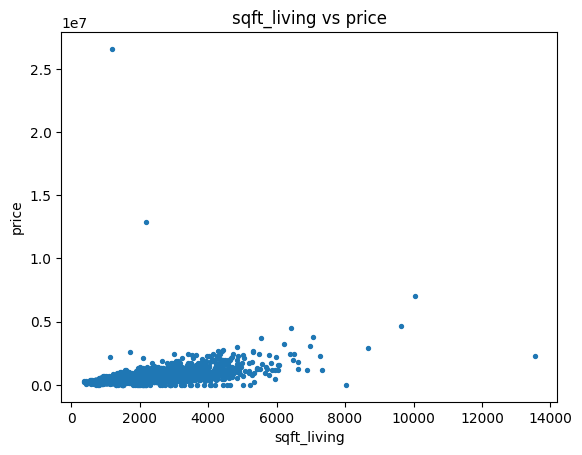

In [11]:
col = "sqft_living" if "sqft_living" in X.columns else X.columns[0]

plt.figure()
plt.scatter(X[col], y, s=8)
plt.xlabel(col)
plt.ylabel("price")
plt.title(f"{col} vs price")
plt.show()

Linear Regression MSE: 986921767056.0947
Linear Regression RMSE: 993439.362546147


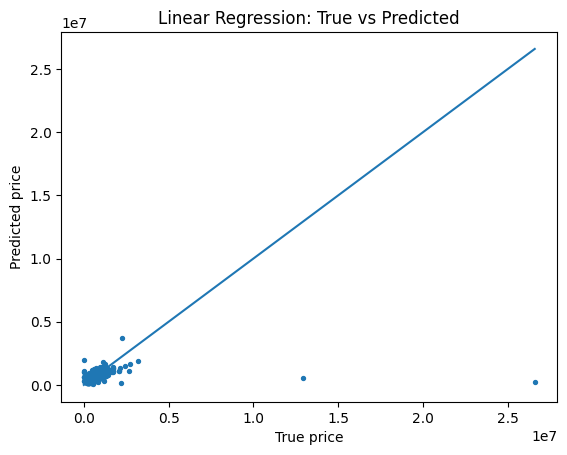

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin = LinearRegression()
lin.fit(X_train, y_train)

pred = lin.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("Linear Regression MSE:", mse)
print("Linear Regression RMSE:", rmse)

plt.figure()
plt.scatter(y_test, pred, s=8)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("Linear Regression: True vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

In [13]:
median_price = y.median()
y_bin = (y > median_price).astype(int)

print("Median price:", median_price)
print("Class balance (0=below median, 1=above):")
print(y_bin.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

logit.fit(X_train, y_train)
pred_cls = logit.predict(X_test)
acc = accuracy_score(y_test, pred_cls)
print("Logistic Regression accuracy:", acc)

Median price: 460943.46153850004
Class balance (0=below median, 1=above):
price
0    0.5
1    0.5
Name: proportion, dtype: float64
Logistic Regression accuracy: 0.7456521739130435


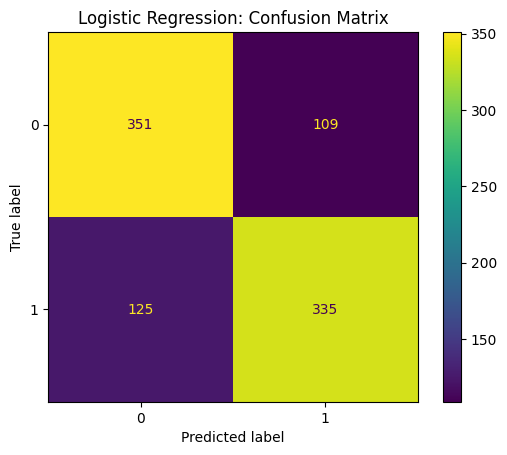

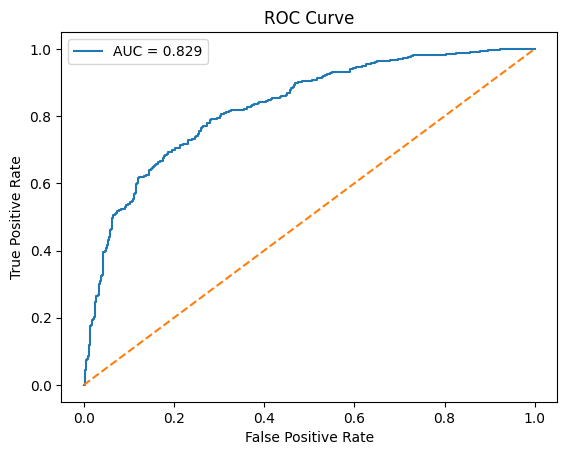

In [14]:
cm = confusion_matrix(y_test, pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression: Confusion Matrix")
plt.show()

proba = logit.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

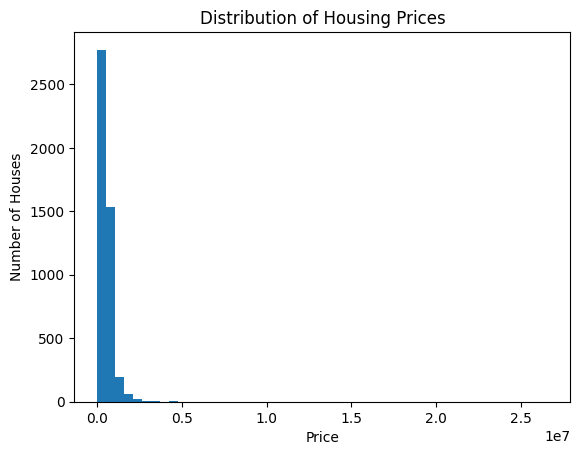

In [15]:
plt.figure()
plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Housing Prices")
plt.show()

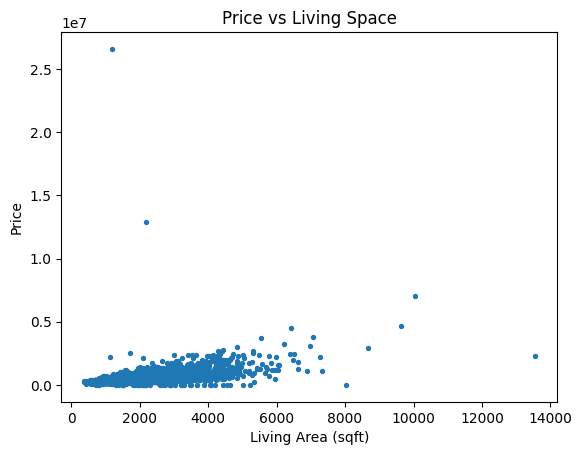

In [16]:
plt.figure()
plt.scatter(df["sqft_living"], df["price"], s=8)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs Living Space")
plt.show()

In [18]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [19]:
df = df.copy()

# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract zip (last 5 digits)
df["zip"] = df["statezip"].astype(str).str.extract(r"(\d{5})")[0]

# Identify "condo/apartment-like" (proxy: small lot + no/low floors)
df["is_condo_proxy"] = (df["sqft_lot"] <= 2000).astype(int)

# Modern proxy (built or renovated recently)
df["modern_proxy"] = ((df["yr_built"] >= 2000) | (df["yr_renovated"] >= 2000)).astype(int)

df[["date","price","city","statezip","zip","sqft_lot","floors","is_condo_proxy","modern_proxy"]].head()

,date,price,city,statezip,zip,sqft_lot,floors,is_condo_proxy,modern_proxy
0,2014-05-02,313000.0,Shoreline,WA 98133,98133,7912,1.5,0,1
1,2014-05-02,2384000.0,Seattle,WA 98119,98119,9050,2.0,0,0
2,2014-05-02,342000.0,Kent,WA 98042,98042,11947,1.0,0,0
3,2014-05-02,420000.0,Bellevue,WA 98008,98008,8030,1.0,0,0
4,2014-05-02,550000.0,Redmond,WA 98052,98052,10500,1.0,0,0


In [21]:
city_stats = (df.groupby("city")
              .agg(median_price=("price","median"),
                   count=("price","size"),
                   median_sqft=("sqft_living","median"))
              .sort_values("median_price", ascending=False))

city_stats.head(10)

,median_price,count,median_sqft
city,,,
Medina,2100000.0,11,4040.0
Yarrow Point,1397000.0,4,2645.0
Clyde Hill,1300000.0,11,3300.0
Mercer Island,948750.0,86,3055.0
Beaux Arts Village,745000.0,1,1490.0
Bellevue,721500.0,286,2450.0
Sammamish,665000.0,175,2810.0
Redmond,638000.0,235,2380.0
Newcastle,602500.0,33,2550.0


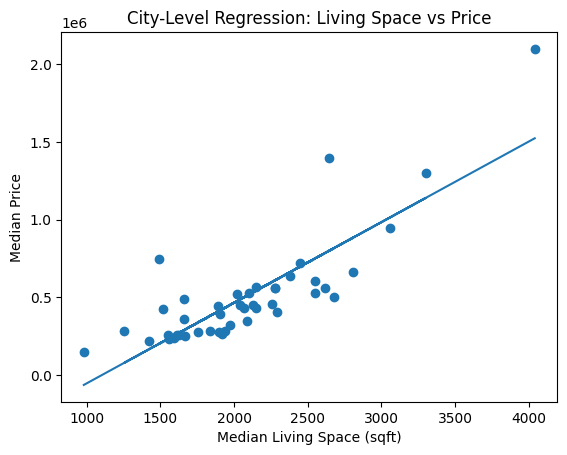

In [33]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X_city = city_stats["median_sqft"].values.reshape(-1,1)
y_city = city_stats["median_price"].values

# Fit regression
model = LinearRegression()
model.fit(X_city, y_city)

# Predict line
y_pred = model.predict(X_city)

# Plot
plt.figure()

plt.scatter(city_stats["median_sqft"], city_stats["median_price"])

plt.plot(city_stats["median_sqft"], y_pred)

plt.xlabel("Median Living Space (sqft)")
plt.ylabel("Median Price")
plt.title("City-Level Regression: Living Space vs Price")

plt.show()

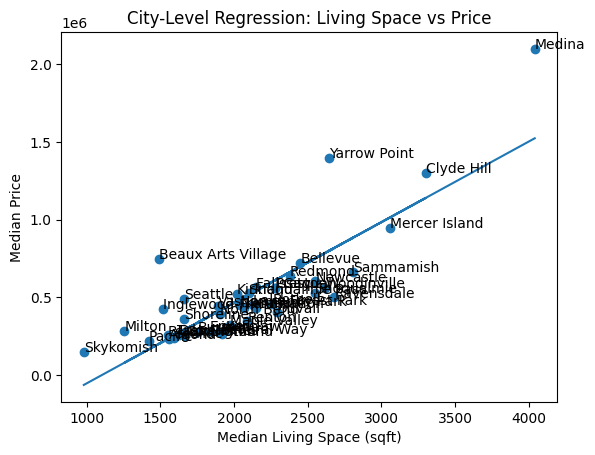

In [34]:
plt.figure()

plt.scatter(city_stats["median_sqft"], city_stats["median_price"])

for city in city_stats.index:
    plt.text(city_stats.loc[city,"median_sqft"],
             city_stats.loc[city,"median_price"],
             city)

plt.plot(city_stats["median_sqft"], y_pred)

plt.xlabel("Median Living Space (sqft)")
plt.ylabel("Median Price")
plt.title("City-Level Regression: Living Space vs Price")

plt.show()

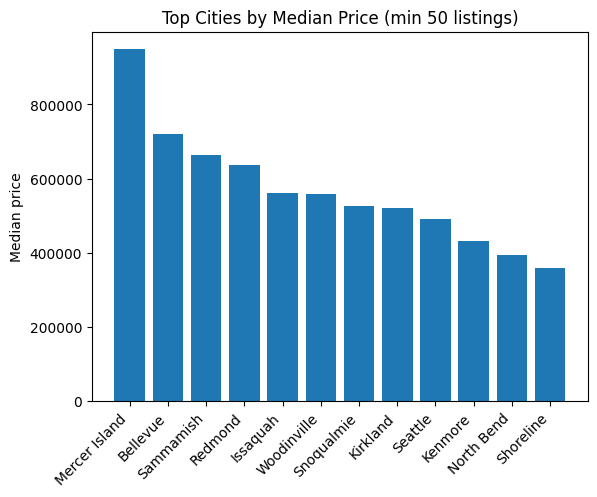

In [22]:
big_cities = city_stats[city_stats["count"] >= 50].head(12)

plt.figure()
plt.bar(big_cities.index, big_cities["median_price"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Median price")
plt.title("Top Cities by Median Price (min 50 listings)")
plt.show()

In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients.head(10)

,Feature,Coefficient
5,waterfront,382459.666353
4,floors,69824.740108
6,view,44755.841775
1,bathrooms,36520.440676
7,condition,29335.539392
2,sqft_living,186.049845
8,sqft_above,96.860817
9,sqft_basement,89.189028
11,yr_renovated,8.259917
3,sqft_lot,-0.514414


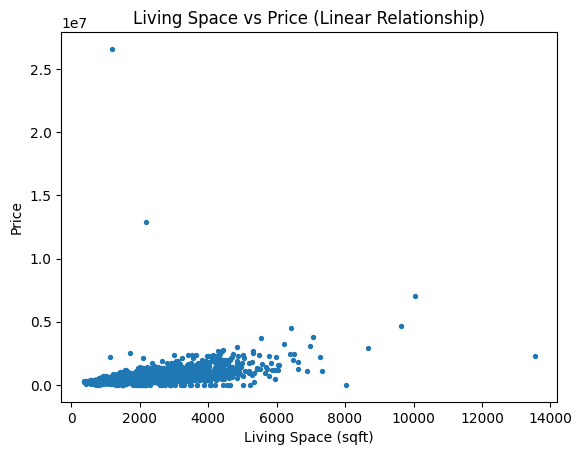

In [26]:
plt.figure()
plt.scatter(df["sqft_living"], df["price"], s=8)
plt.xlabel("Living Space (sqft)")
plt.ylabel("Price")
plt.title("Living Space vs Price (Linear Relationship)")
plt.show()

In [27]:
median_price = df["price"].median()
y_bin = (df["price"] > median_price).astype(int)

In [30]:
log_coefs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logit.named_steps["clf"].coef_[0]
})

log_coefs.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
2,sqft_living,0.867142
8,sqft_above,0.750103
1,bathrooms,0.471223
9,sqft_basement,0.419693
4,floors,0.415970
6,view,0.135220
7,condition,0.123956
5,waterfront,0.032384
11,yr_renovated,-0.002930
3,sqft_lot,-0.007444


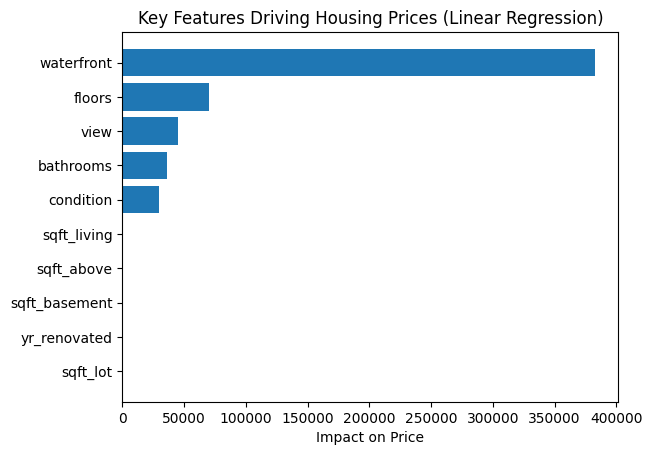

In [32]:
plt.figure()

top_features = coefficients.head(10)

plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Impact on Price")
plt.title("Key Features Driving Housing Prices (Linear Regression)")
plt.gca().invert_yaxis()

plt.show()

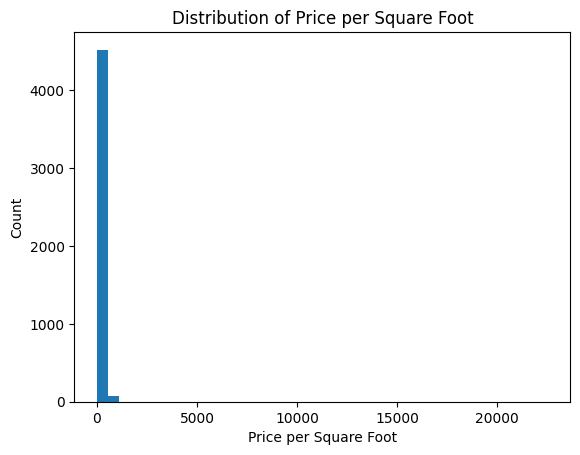

In [31]:
X["price_per_sqft"] = df["price"] / df["sqft_living"]

plt.figure()
plt.hist(X["price_per_sqft"], bins=40)
plt.xlabel("Price per Square Foot")
plt.ylabel("Count")
plt.title("Distribution of Price per Square Foot")
plt.show()

In [36]:
print("X columns now:", len(X.columns))
print("Model coef length:", len(logit.named_steps["clf"].coef_[0]))

X columns now: 13
Model coef length: 12


In [37]:
feature_names = X_train.columns  # features used when the model was fit
coefs = logit.named_steps["clf"].coef_[0]

log_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
}).sort_values("Coefficient", ascending=False)

log_coefs.head(10)

,Feature,Coefficient
2,sqft_living,0.867142
8,sqft_above,0.750103
1,bathrooms,0.471223
9,sqft_basement,0.419693
4,floors,0.415970
6,view,0.135220
7,condition,0.123956
5,waterfront,0.032384
11,yr_renovated,-0.002930
3,sqft_lot,-0.007444


In [38]:
feature_names = X_train.columns  # features used when the model was fit
coefs = logit.named_steps["clf"].coef_[0]

log_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
}).sort_values("Coefficient", ascending=False)

log_coefs.head(10)

,Feature,Coefficient
2,sqft_living,0.867142
8,sqft_above,0.750103
1,bathrooms,0.471223
9,sqft_basement,0.419693
4,floors,0.415970
6,view,0.135220
7,condition,0.123956
5,waterfront,0.032384
11,yr_renovated,-0.002930
3,sqft_lot,-0.007444


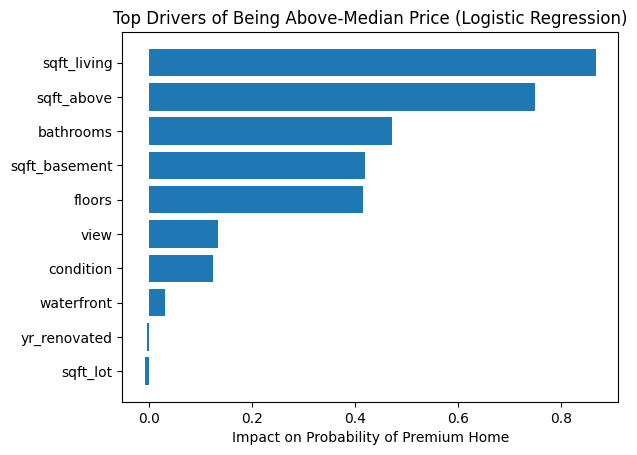

In [39]:
top = log_coefs.head(10)

plt.figure()
plt.barh(top["Feature"], top["Coefficient"])
plt.xlabel("Impact on Probability of Premium Home")
plt.title("Top Drivers of Being Above-Median Price (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

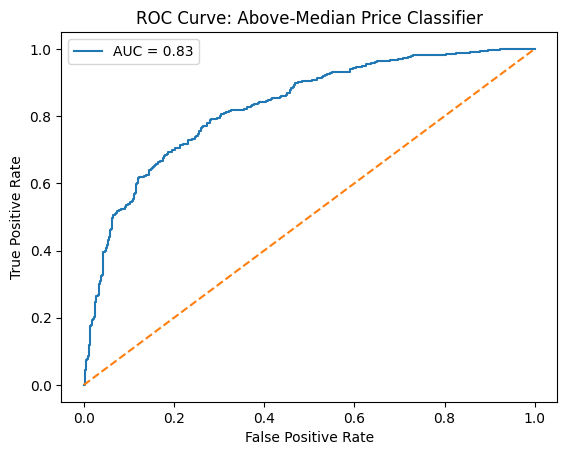

In [40]:
proba = logit.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Above-Median Price Classifier")
plt.legend()
plt.show()

In [2]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


In [3]:
# # Create data for linear regression (predicting real values)
# X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# # Create data for logistic regression (predicting classes)
# X_clf, y_clf = make_classification(n_samples=100, n_features=1,
#                                    n_informative=1, n_redundant=0,
#                                    n_clusters_per_class=1, random_state=42)

# Load the KC Housing dataset
df = pd.read_csv('KC_housing_data.csv')

# Drop irrelevant columns
df = df.drop(columns=['id', 'date'], errors='ignore')
df = df.dropna()  # remove any rows with missing values

# ✅ Linear Regression: predict continuous house price
X_reg = df[['sqft_living']].values   # single feature (like original n_features=1)
y_reg = df['price'].values

# ✅ Logistic Regression: classify expensive (1) vs not expensive (0)
X_clf = df[['sqft_living']].values
y_clf = (df['price'] > df['price'].median()).astype(int).values


In [4]:
# Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_reg, y_reg)
lin_pred = lin_model.predict(X_reg)


In [5]:
# Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_clf, y_clf)
log_pred = log_model.predict(X_clf)

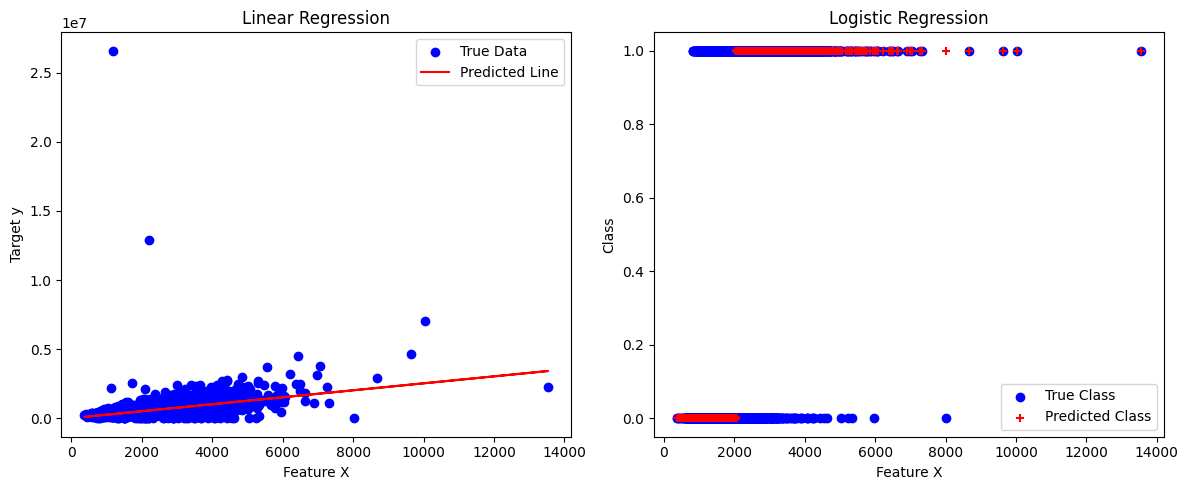

In [6]:
# Plot results for Linear Regression
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_reg, y_reg, color='blue', label='True Data')
plt.plot(X_reg, lin_pred, color='red', label='Predicted Line')
plt.title('Linear Regression')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()

# Plot results for Logistic Regression
plt.subplot(1,2,2)
plt.scatter(X_clf, y_clf, color='blue', label='True Class')
plt.scatter(X_clf, log_pred, color='red', marker='+', label='Predicted Class')
plt.title('Logistic Regression')
plt.xlabel('Feature X')
plt.ylabel('Class')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# Print metrics for comparison
print("Linear Regression mean squared error:", mean_squared_error(y_reg, lin_pred))
print("Logistic Regression accuracy:", accuracy_score(y_clf, log_pred))

Linear Regression mean squared error: 258959628843.36646
Logistic Regression accuracy: 0.7302173913043478


## Reflection: Linear vs Logistic Regression on KC Housing Data

**Linear Regression** was used to predict the actual house price — a continuous value.
The model learned a relationship between features like `sqft_living` and the price in dollars.
The MSE tells us how far off our predictions were on average (in squared dollars).
A lower MSE means more accurate price predictions.

**Logistic Regression** was used to classify houses as "expensive" (above median price) or "not expensive".
Instead of predicting an exact value, it outputs a probability (0 to 1) and assigns a class label.
Accuracy tells us what percentage of houses were correctly classified.

**Key Difference:**
- Use **Linear Regression** when you need an exact number (e.g., "This house costs $450,000")
- Use **Logistic Regression** when you need a category (e.g., "Is this house expensive? Yes/No")

On the KC housing dataset, logistic regression achieved high accuracy because the median
clearly separates the data into two distinct groups. Linear regression, however, is more
informative for real-world pricing applications where the exact value matters.
